   Latest: Time (s)  Latest: Potential (V)
0                 0               0.294624
1                 2               0.293400
2                 4               0.294624
3                 6               0.293094
4                 8               0.296154


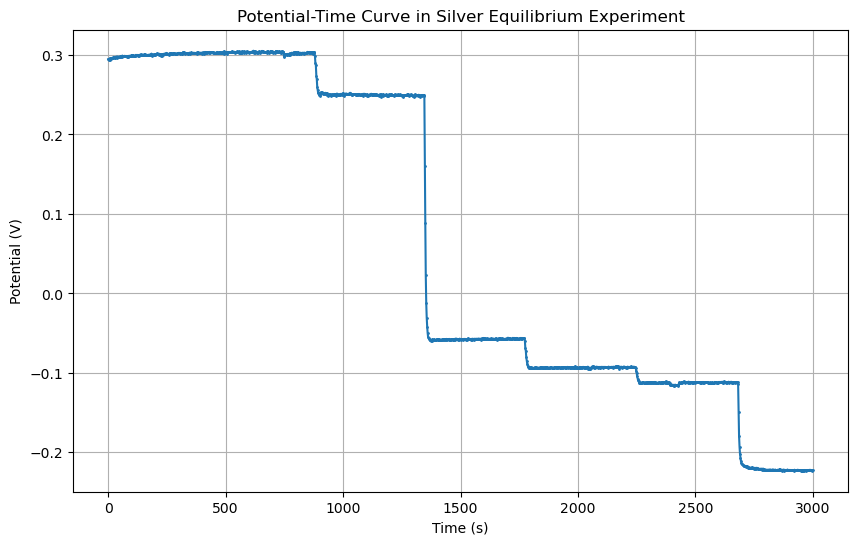

In [ ]:
import pandas
import matplotlib.pyplot as plt

data = pandas.read_csv('silver_equilibrium.csv')
print(data.head())


plt.figure(figsize=(10, 6))
plt.plot(data['Latest: Time (s)'], data['Latest: Potential (V)'], marker='o', markersize=1, linestyle='-')
plt.title('Potential-Time Curve in Silver Equilibrium Experiment')
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')
plt.grid()
plt.show()

Calibration constant:
C = 0.540500 ± 0.000713 V

Derived fitting data:
V = 10 mL | [Ag+] = 8.0396e-11 ± 2.65e-12 M | [complex] = 8.3333e-05 M | [NH3] = 0.16667 M | x = -0.77815 | y = 6.01558 ± 0.01430
V = 20 mL | [Ag+] = 2.0155e-11 ± 6.61e-13 M | [complex] = 7.6923e-05 M | [NH3] = 0.30769 M | x = -0.51188 | y = 6.58166 ± 0.01424
V = 30 mL | [Ag+] = 9.4700e-12 ± 3.11e-13 M | [complex] = 7.1429e-05 M | [NH3] = 0.42857 M | x = -0.36798 | y = 6.87752 ± 0.01425

Weighted linear fit results:
Slope      = 2.104451 ± 0.048507
Intercept  = 7.654662 ± 0.028018
R^2        = 0.999928

Derived from intercept:
Kf(graph)  = 4.5150e+07 ± 2.91e+06



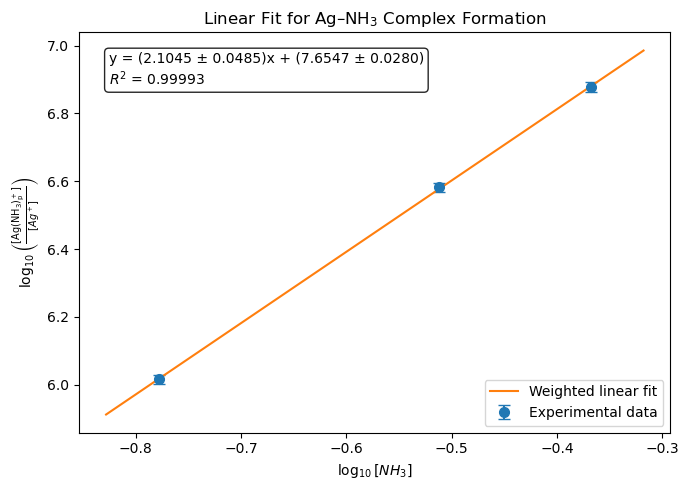

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


S = 0.0592  
E0 = 0.3037
sigma_E0 = 0.0007131


E_vals = np.array([
    -0.05711,  
    -0.09268,  
    -0.11210    
])

sigma_E_vals = np.array([
    0.0004560,
    0.0004496,
    0.0004502
])


V_added = np.array([10.0, 20.0, 30.0])
M_NH3_stock = 2.00
Ag_total_initial = 1.000e-4  


C = E0 - S * np.log10(1.000e-4)
sigma_C = sigma_E0

print("Calibration constant:")
print(f"C = {C:.6f} ± {sigma_C:.6f} V")
print()


Ag_free = 10 ** ((E_vals - C) / S)


sigma_Ag_free = Ag_free * np.log(10) / S * np.sqrt(sigma_E_vals**2 + sigma_C**2)


V_total = 110.0 + V_added


complex_conc = Ag_total_initial * 100.0 / V_total


NH3_free = V_added * M_NH3_stock / V_total


x = np.log10(NH3_free)


y = np.log10(complex_conc / Ag_free)

sigma_y = sigma_Ag_free / (Ag_free * np.log(10))

print("Derived fitting data:")
for i in range(len(V_added)):
    print(
        f"V = {V_added[i]:.0f} mL | "
        f"[Ag+] = {Ag_free[i]:.4e} ± {sigma_Ag_free[i]:.2e} M | "
        f"[complex] = {complex_conc[i]:.4e} M | "
        f"[NH3] = {NH3_free[i]:.5f} M | "
        f"x = {x[i]:.5f} | y = {y[i]:.5f} ± {sigma_y[i]:.5f}"
    )
print()


def linear_model(x, m, b):
    return m * x + b

popt, pcov = curve_fit(
    linear_model,
    x,
    y,
    sigma=sigma_y,
    absolute_sigma=True
)

slope, intercept = popt
slope_std, intercept_std = np.sqrt(np.diag(pcov))

y_fit = linear_model(x, slope, intercept)

ss_res = np.sum((y - y_fit)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - ss_res / ss_tot

print("Weighted linear fit results:")
print(f"Slope      = {slope:.6f} ± {slope_std:.6f}")
print(f"Intercept  = {intercept:.6f} ± {intercept_std:.6f}")
print(f"R^2        = {r_squared:.6f}")
print()


Kf_graph = 10 ** intercept

sigma_Kf_graph = np.log(10) * Kf_graph * intercept_std

print("Derived from intercept:")
print(f"Kf(graph)  = {Kf_graph:.4e} ± {sigma_Kf_graph:.2e}")
print()


x_line = np.linspace(min(x) - 0.05, max(x) + 0.05, 300)
y_line = linear_model(x_line, slope, intercept)

plt.figure(figsize=(7, 5))

plt.errorbar(
    x, y, yerr=sigma_y,
    fmt='o', capsize=4, markersize=7,
    label='Experimental data'
)

plt.plot(
    x_line, y_line, '-',
    label='Weighted linear fit'
)

eq_text = (
    f'y = ({slope:.4f} ± {slope_std:.4f})x + ({intercept:.4f} ± {intercept_std:.4f})\n'
    f'$R^2$ = {r_squared:.5f}'
)

plt.text(
    0.05, 0.95, eq_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
)

plt.xlabel(r'$\log_{10}[NH_3]$')
plt.ylabel(r'$\log_{10}\left(\frac{[\mathrm{Ag(NH_3)_p^+}]}{[Ag^+]}\right)$')
plt.title(r'Linear Fit for Ag–NH$_3$ Complex Formation')
plt.legend()
plt.tight_layout()
plt.show()